In [1]:
%pip install seaborn

Matplotlib is building the font cache; this may take a moment.


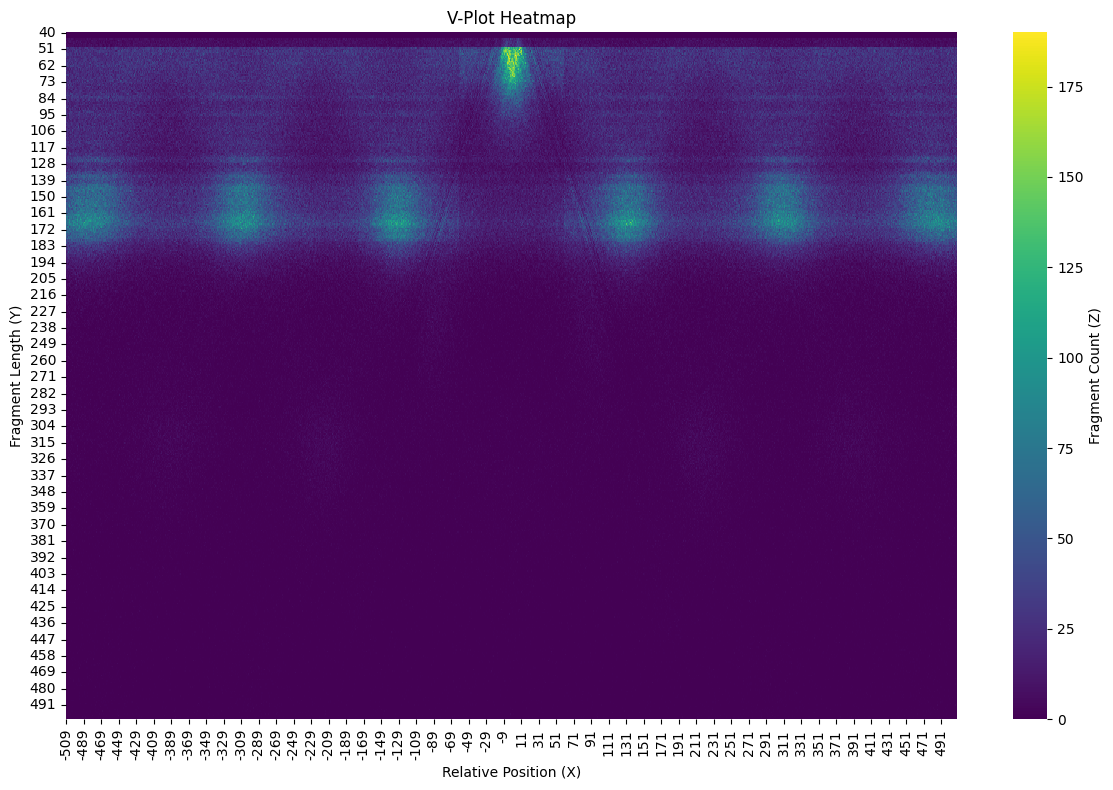

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("mapped.bed.gz", sep="\t", header=None, compression="gzip")
df["C1"] = (df[2] + df[3]) // 2         
df["C2"] = (df[8] + df[9]) // 2         
df["X"] = df["C2"] - df["C1"]           
df["Y"] = df[9] - df[8]                 
heatmap_data = df.groupby(["X", "Y"]).size().reset_index(name="Z")
pivot = heatmap_data.pivot(index="Y", columns="X", values="Z").fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap="viridis", cbar_kws={'label': 'Fragment Count (Z)'})
plt.title("V-Plot Heatmap")
plt.xlabel("Relative Position (X)")
plt.ylabel("Fragment Length (Y)")
plt.tight_layout()
plt.show()
